# Lab 4 - From a camera image to a position in the lane

Your Duckiebot's camera produces a 640x480 picture about thirty times a second.
Somewhere in that picture are the lane markings, and somewhere in the numbers
that describe them is the answer to the only question the robot actually cares
about: **Where am I in the lane, and which way am I facing in it?**

This notebook walks the whole way from one to the other.

**You will implement sections 1-8 in your ROS node.** That is the detection
half: turning an image into a list of line segments, each one labelled with a
colour and pointed the right way round.

---

## The pipeline

```
   camera image
        |
   1. resize + crop               
   2. convert to HSV              
   3. threshold each colour       
   4. clean up with morphology    
   5. find edges                  
   6. keep edges inside each mask 
   7. fit line segments           
   8. orient each segment           
```

In [1]:
%pip install --quiet numpy "opencv-python<5" matplotlib pyyaml ipympl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import yaml
import matplotlib.pyplot as plt

# The data folder where you can insert 
DATA = "data"

print("OpenCV", cv2.__version__)


def show(*images, titles=None, size=4, cmap=None):
    '''Draw one or more images side by side, converting BGR to RGB as needed.'''
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(size * n, size))
    axes = np.atleast_1d(axes)
    for ax, img in zip(axes, images):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap or "gray", vmin=0, vmax=255)
        ax.axis("off")
    if titles:
        for ax, t in zip(axes, titles):
            ax.set_title(t, fontsize=10)
    plt.tight_layout()
    plt.show()

def draw(image, lines, color=(255, 0, 0)):
    out = image.copy()
    for x1, y1, x2, y2 in lines:
        cv2.line(out, (x1, y1), (x2, y2), color, 1, cv2.LINE_AA)
    return out

OpenCV 4.14.0


## 1. An image is just an array

Load one and look at what you actually have.
Use the mouse to hover over the image and see what the RGB color values are.

type    <class 'numpy.ndarray'>
shape   (480, 640, 3)  <- (rows, columns, channels) = (height, width, 3)
dtype   uint8  <- one byte per channel, so 0..255


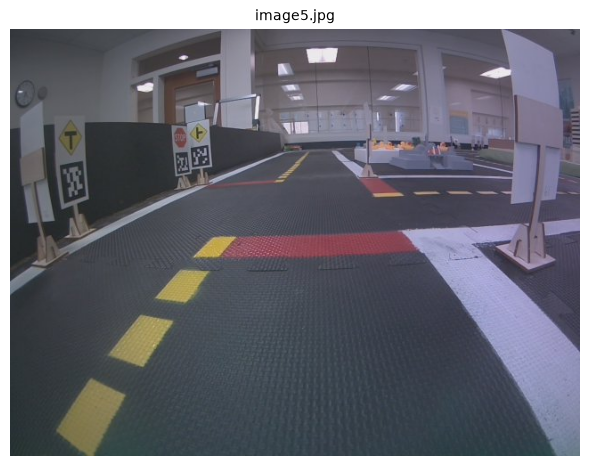

In [3]:
# TODO you can place your own images in the data folder and select them here!
bgr = cv2.imread(f"{DATA}/image5.jpg")
print("type   ", type(bgr))
print("shape  ", bgr.shape, " <- (rows, columns, channels) = (height, width, 3)")
print("dtype  ", bgr.dtype, " <- one byte per channel, so 0..255")

show(bgr, titles=["image5.jpg"], size=6)

**OpenCV stores colour as B, G, R** - the reverse of the R, G, B order almost
everything else uses. `imread` gives you BGR, `imshow` in matplotlib expects
RGB, which is why `show()` above converts. 

### Cropping and Resizing

Two separate reasons for those two steps, and it is worth keeping them apart:

* Resize is about speed - What rate can your computer process these images at? Smaller images process faster.
* Crop is about relevance - What part of the image do you want to see?

resizing (640, 480) -> (300, 400)
original 640x480 = 307,200 pixels
resized  300x400 = 120,000 pixels
cropped  300x280 = 84,000 pixels

that is 4x less data per frame


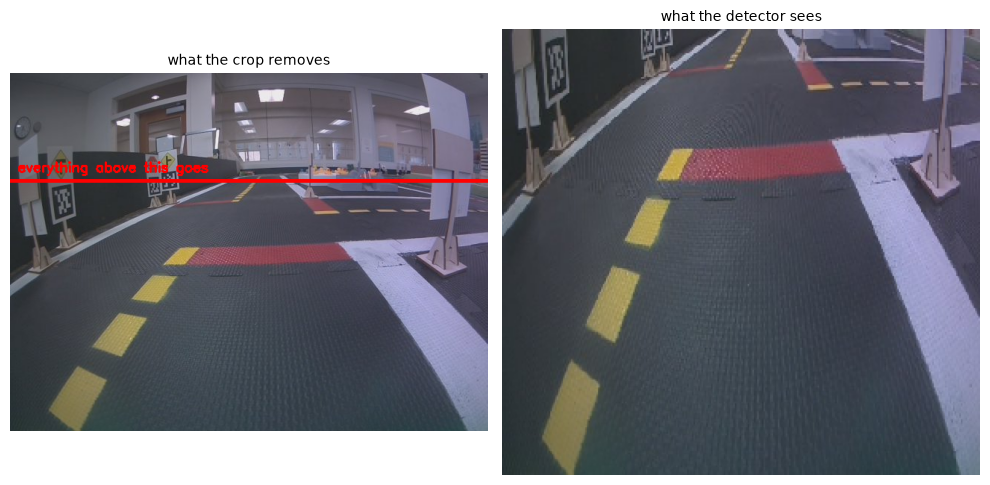

In [4]:
# TODO: Tune parameters to what you think it should be for your bot.
IMG_SIZE = (300, 400)        # (width, height) original size is (640, 480)
TOP_CUTOFF = 0.3      # fraction of top of image to throw away (to remove non-road or far away road)

# Resize 
original_size = bgr.shape[1], bgr.shape[0]
if original_size != IMG_SIZE:
    print(f"resizing {original_size} -> {IMG_SIZE}")
    small = cv2.resize(bgr, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
else:
    small = bgr

# Crop
ROWS_CUTTOFF = int(TOP_CUTOFF * small.shape[0])
cropped = small[ROWS_CUTTOFF:] # TODO USE ROWS_CUTOFF to crop the top of the image and store it in cropped.


print(f"original {bgr.shape[1]}x{bgr.shape[0]} = {bgr.shape[0]*bgr.shape[1]:,} pixels")
print(f"resized  {small.shape[1]}x{small.shape[0]} = {small.shape[0]*small.shape[1]:,} pixels")
print(f"cropped  {cropped.shape[1]}x{cropped.shape[0]} = {cropped.shape[0]*cropped.shape[1]:,} pixels")
print(f"\nthat is {bgr.size / cropped.size:.0f}x less data per frame")

# Crop line drawn on the full-size image to see what is being thrown away.
marked = bgr.copy()
y = int(TOP_CUTOFF * bgr.shape[0])
cv2.line(marked, (0, y), (bgr.shape[1], y), (0, 0, 255), 3)
cv2.putText(marked, "everything above this goes", (10, y - 12),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

show(marked, cropped, titles=["what the crop removes", "what the detector sees"], size=5)

## 2. Why HSV and not RGB

You are about to say "this pixel is white" and "this pixel is yellow". Try to
write that rule in BGR and you will find it is a mess, because in BGR the
*brightness* of a colour and the *colour itself* are tangled together across
all three numbers. A yellow line in shadow and the same line in sunlight have
completely different BGR values.

HSV pulls them apart:

| channel | meaning | OpenCV range |
|---|---|---|
| **H**ue | which colour it is, as an angle round the colour wheel | 0-179 |
| **S**aturation | how vivid, from grey to pure colour | 0-255 |
| **V**alue | how bright | 0-255 |

Note H only goes to **179**, not 359 - it is an angle halved to fit in a byte.
It also **wraps**: 179 and 0 are neighbours. That matters in a moment.

Look at these three grayscale images showing the HSV channels will help you give you an intuition for how to distinguish between white and yellow lines!

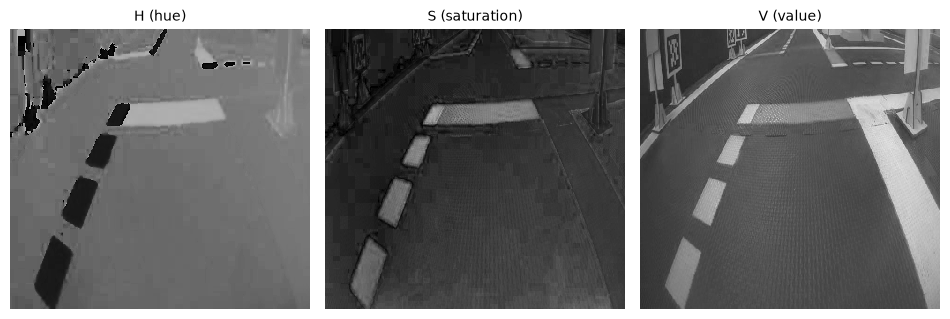

In [5]:
hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

show(h, s, v, titles=["H (hue)", "S (saturation)", "V (value)"], size=3.2)

                           H     S     V
road                      96    28    46
white line               111    30    84
yellow line               75     5   106
red_line                  96    28    45


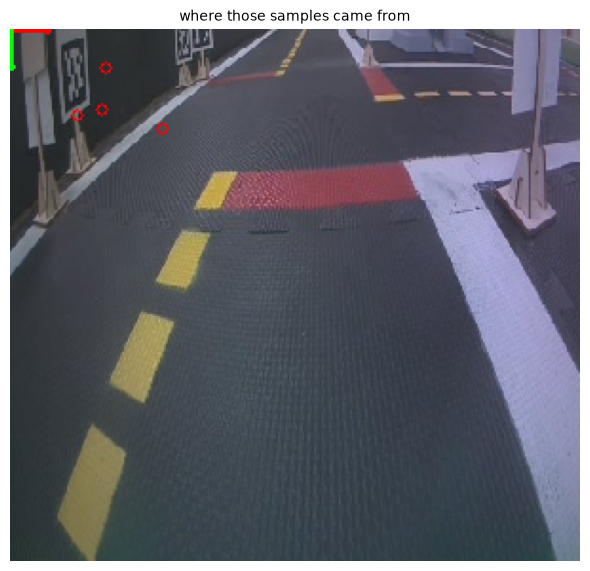

In [6]:
# TODO: Read the actual numbers off three places in the image. 
# Fill in the x, y coordinates as tuple (x, y)
points = {
    "road":  (50, 20)            ,
    "white line":  (80, 52)        ,
    "yellow line":   (35, 45)        ,
    "red_line":      (48, 42)  ,
}

# Print the HSV values for the points of interest. 
print(f"{'':22s} {'H':>5s} {'S':>5s} {'V':>5s}")
for name, (x, y) in points.items():
    print(f"{name:22s} {hsv[y,x,0]:5d} {hsv[y,x,1]:5d} {hsv[y,x,2]:5d}")

# Mark the points of interest on the image
marked = cropped.copy()
for name, (x, y) in points.items():
    cv2.circle(marked, (x, y), 3, (0, 0, 255), 1)

# Draw the x, y coorinate system arrows
cv2.arrowedLine(marked, (0, 0), (20, 0), (0, 0, 255), 2)  # x-axis (red)
cv2.arrowedLine(marked, (0, 0), (0, 20), (0, 255, 0), 2)  # y-axis (green)

show(marked, titles=["where those samples came from"], size=6)

## 3. Thresholding - your first real decision

`cv2.inRange(hsv, low, high)` returns a **mask**: a binary array the same size as the
image, with values of 255 where every channel fell inside the range and 0 everywhere else.

Fill in the four bounds below. Use starting HSV values from the points of interest above!

Tip:
- If you cannot separate them with thresholds alone, you can always subtract one
mask from the other - `cv2.bitwise_and(white, cv2.bitwise_not(yellow))` removes
anything the yellow detector claimed. Use this only after your thresholds
are as good as you can get them.

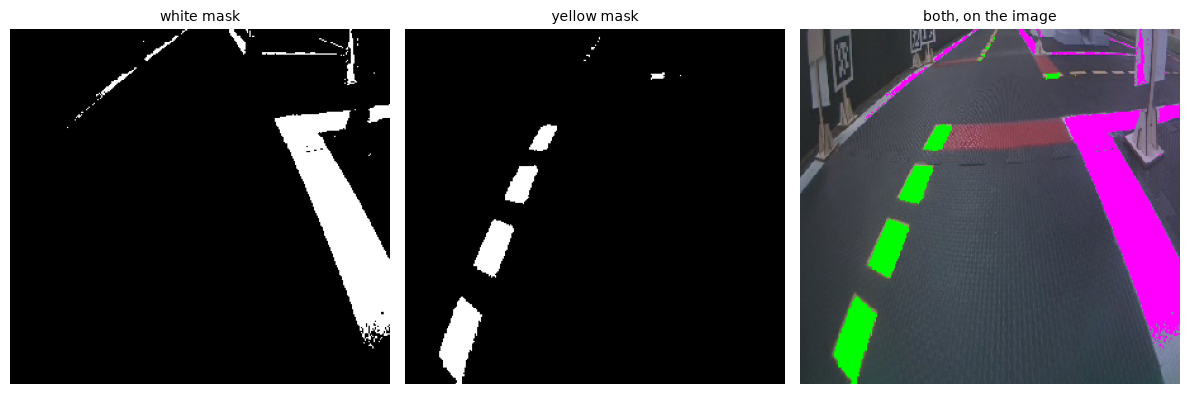

In [7]:
# TODO: fill in the four bounds. Each is [H, S, V].
#
# Use the numbers you printed in section 2 as a starting point, then adjust
# while watching the pictures below.
WHITE_LOW,  WHITE_HIGH  = np.array([100, 20, 170]), np.array([130, 75, 250])
YELLOW_LOW, YELLOW_HIGH = np.array([5, 75, 50]), np.array([55, 190, 255])

mask_white  = cv2.inRange(hsv, WHITE_LOW,  WHITE_HIGH)
mask_yellow = cv2.inRange(hsv, YELLOW_LOW, YELLOW_HIGH)

overlay = cropped.copy()
overlay[mask_white  > 0] = (255, 0, 255)   # magenta
overlay[mask_yellow > 0] = (0, 255, 0)     # green, NOTE: this will overwrite magenta if both are true!
show(mask_white, mask_yellow, overlay,
     titles=["white mask", "yellow mask", "both, on the image"], size=4)

### Red, and why it needs two ranges

Hue is an **angle**, and OpenCV cuts that circle open at 0. Red sits exactly on
the cut - some red pixels land near H=0 and some near H=179. No single
`low <= H <= high` pair can catch both, so red takes two ranges OR'd together.

NOTE: You may not need both ranges in practice but it is good to know how to handle it!

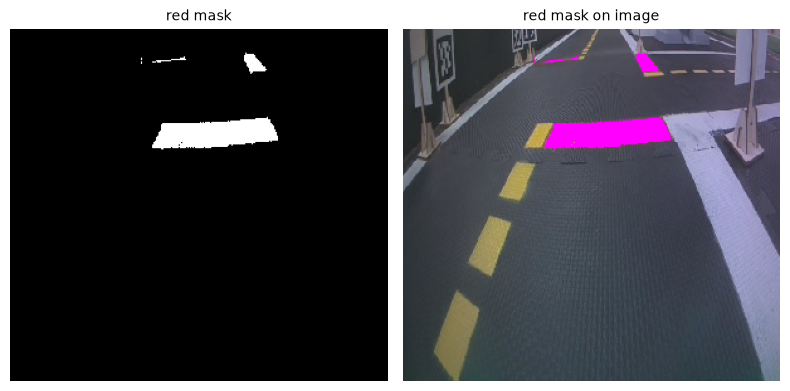

In [8]:
# TODO: Find two ranges, one at each end of the hue circle, combined with
# cv2.bitwise_or. Red near H=0 and red near H=179 are the same colour.
RED_LOW_1, RED_HIGH_1 = np.array([0, 100, 120]), np.array([20, 140, 160])
RED_LOW_2, RED_HIGH_2 = np.array([165, 30, 110]), np.array([255, 255, 200])

# TODO: Write your cv2.inRange calls and combine the two masks with cv2.bitwise_or

# mask_red = cv2.bitwise_or(cv2.inRange(hsv, RED_LOW_1, RED_HIGH_1), cv2.inRange(hsv, RED_LOW_2, RED_HIGH_2))
# mask_red = cv2.inRange(hsv, RED_LOW_1, RED_HIGH_1)
mask_red = cv2.inRange(hsv, RED_LOW_2, RED_HIGH_2)
overlay = cropped.copy()
overlay[mask_red  > 0] = (255, 0, 255)   # magenta
show(mask_red, overlay, titles=["red mask", "red mask on image"], size=4)


## 4. Morphology - and the real reason for it

`erode` shrinks a mask, `dilate` grows it. Eroding first removes isolated
speckle; dilating afterwards puts the surviving regions back to roughly their
original size.

But there is a second reason to dilate, and it is the one that actually
matters. In section 6 you are going to intersect these masks with **edges**,
and an edge sits on the *boundary* of a coloured region - right at the mask's
rim, or a pixel outside it. An undilated mask barely touches its own edges.
Dilating past the original size is what makes the intersection find anything at
all.

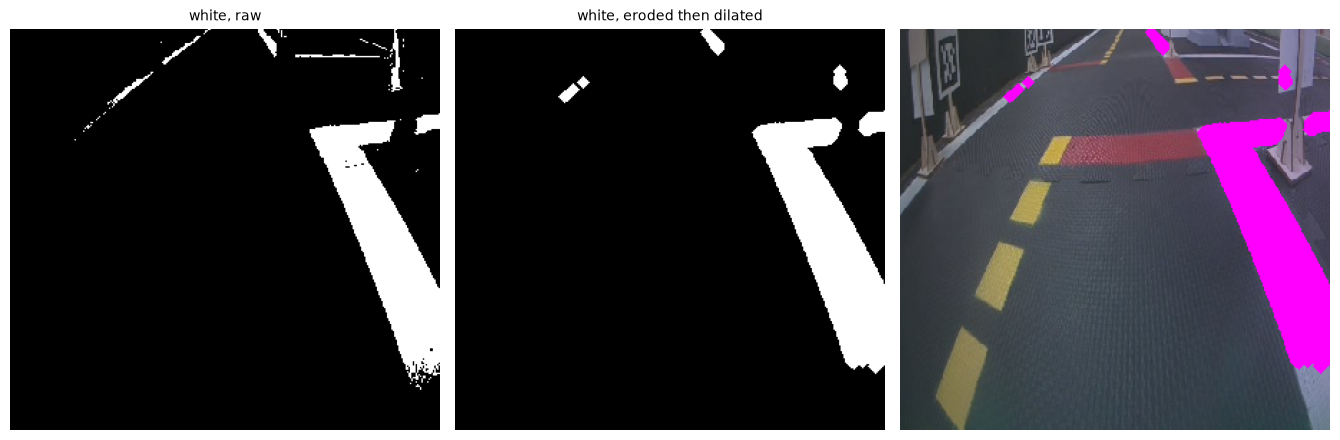

white   7181 ->  7712 px
yellow  2861 ->  3528 px


In [9]:
# TODO: Tune these parameters 
KERNEL_SIZE = 3
ERODE_ITERS = 2
DILATE_ITERS = 4

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (KERNEL_SIZE, KERNEL_SIZE))

def clean(mask):
    # TODO: erode to drop speckle, then dilate. Remember the second reason for
    # the dilation - the mask has to reach out over the Canny edges you find in
    # section 6.
    m = cv2.erode(mask, kernel, iterations=ERODE_ITERS)          # TODO: cv2.erode(...)
    m = cv2.dilate(m, kernel, iterations=DILATE_ITERS)             # TODO: cv2.dilate(...)
    return m

clean_white  = clean(mask_white)
clean_yellow = clean(mask_yellow)
clean_red    = clean(mask_red)
overlay = cropped.copy()
overlay[clean_white  > 0] = (255, 0, 255)   # magenta

show(mask_white, clean_white, overlay, titles=["white, raw", "white, eroded then dilated"], size=4.5)
print(f"white  {int(mask_white.sum()//255):5d} -> {int(clean_white.sum()//255):5d} px")
print(f"yellow {int(mask_yellow.sum()//255):5d} -> {int(clean_yellow.sum()//255):5d} px")

## 5. Edges

`cv2.Canny` finds places where brightness changes sharply. It takes two
thresholds: gradients above the high one definitely start an edge, gradients
between the two only continue an edge already started, and anything below the
low one is discarded.

**Canny runs once, on the whole image - not once per colour.** An edge is an
edge; the colour masks are what sort them out afterwards.

TODO: Play with the canny edge thresholds so you know how to tune them and find some good parameters for the lane detection.

Low thresholds trace every speck of texture in the road surface. High ones keep
only the strongest boundaries and start losing the far end of the lane
markings, where the contrast is weakest. You want the lane edges crisp and the
road texture mostly gone.

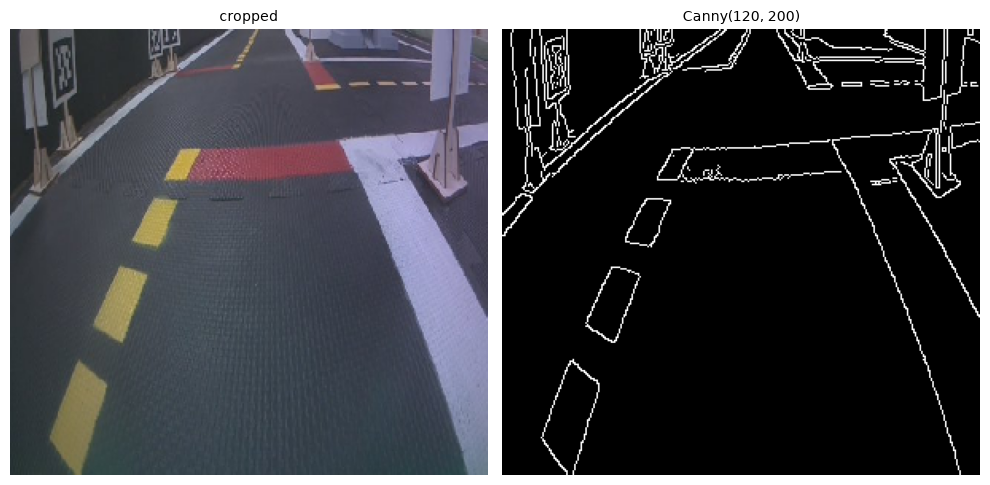

In [10]:
# TODO: Tune these parameters
CANNY_LOW = 120
CANNY_HIGH = 200
edges = cv2.Canny(cropped, CANNY_LOW, CANNY_HIGH, apertureSize=3)
show(cropped, edges, titles=["cropped", f"Canny({CANNY_LOW}, {CANNY_HIGH})"], size=5)

## 6. Colour AND edges - the step that makes this work

Now we can put our color and edge detection together!

You have edges, but no idea which marking each one belongs to. You have colour
masks, but they are solid blobs, and a line-fitter given a solid blob returns
nonsense. **`cv2.bitwise_and` of the two gives you the outline of one specific
marking**, which is exactly what a line-fitter wants.

The cell below fits lines both ways so you can see the difference.

In [11]:
white_edges = cv2.bitwise_and(clean_white, edges)  # TODO use cv2.bitwise_and to combine the clean white mask with the edges

white_lines = cv2.HoughLinesP(white_edges, rho=1, theta=np.pi / 180, threshold=4,
                            minLineLength=3, maxLineGap=3)

show(cv2.cvtColor(white_edges, cv2.COLOR_GRAY2BGR), draw(cropped, white_lines),
     titles=["mask AND edges",
             f"Hough on the intersection"], size=4)

ValueError: not enough values to unpack (expected 4, got 1)

## 7. The Hough transform, and its four knobs

`HoughLinesP` works by letting every lit pixel vote for all the lines that
could pass through it, and returning the lines with enough votes.

| parameter | what it does | too low | too high |
|---|---|---|---|
| `threshold` | votes needed to accept a line | spurious lines | misses faint markings |
| `minLineLength` | shortest segment kept | noise fragments | loses distant markings |
| `maxLineGap` | gap that can be bridged | dashes come out fragmented | unrelated markings get joined |
| `rho`, `theta` | resolution of the vote grid | slow, fragmented | coarse, inaccurate |

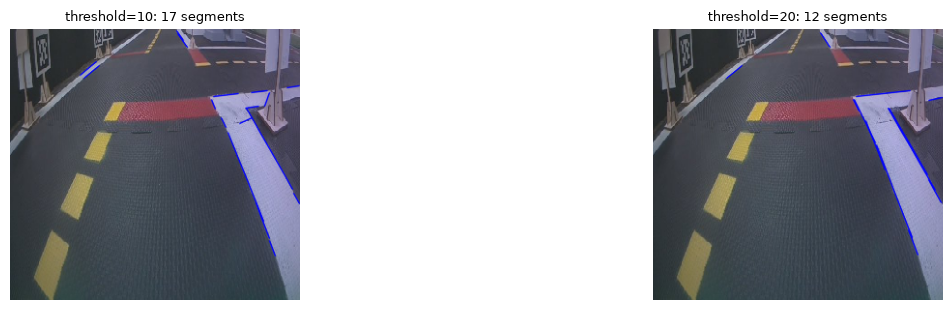

In [ ]:
# COMPARE TWO thresholds 
# TODO change these parameters to see how the number of segments changes.
HOUGH_PARMS1 = (10, 10, 3)   # threshold, minLineLength, maxLineGap
HOUGH_PARMS2 = (20, 10, 10)   # threshold, minLineLength, maxLineGap

fig, axes = plt.subplots(1, 2, figsize=(16, 3.2))

l1 = cv2.HoughLinesP(white_edges, rho=1, theta=np.pi / 180, threshold=HOUGH_PARMS1[0],
                            minLineLength=HOUGH_PARMS1[1], maxLineGap=HOUGH_PARMS1[2])
axes[0].imshow(cv2.cvtColor(draw(cropped, l1), cv2.COLOR_BGR2RGB))
axes[0].set_title(f"threshold={HOUGH_PARMS1[0]}: {len(l1)} segments", fontsize=9)
axes[0].axis("off")

l2 = cv2.HoughLinesP(white_edges, rho=1, theta=np.pi / 180, threshold=HOUGH_PARMS2[0],
                            minLineLength=HOUGH_PARMS2[1], maxLineGap=HOUGH_PARMS2[2])

axes[1].imshow(cv2.cvtColor(draw(cropped, l2), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"threshold={HOUGH_PARMS2[0]}: {len(l2)} segments", fontsize=9)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: settle on the values you liked above, then run all three colours
# through the same pipeline: keep only the edges inside each colour's mask
# (cv2.bitwise_and), and fit segments to what is left.
#
# minLineLength and maxLineGap must both be > 0 - passing 0 trips an assertion
# inside OpenCV.
HOUGH_PARMS = (20, 10, 10)  # TODO (threshold, minLineLength, maxLineGap)
masks = {"WHITE": clean_white, "YELLOW": clean_yellow, "RED": clean_red}
detections = {}

for name, m in masks.items():
    detections[name] = cv2.HoughLinesP(cv2.bitwise_and(m, edges), rho=1, theta=np.pi / 180,
                                         threshold=HOUGH_PARMS[0],
                                         minLineLength=HOUGH_PARMS[1],
                                         maxLineGap=HOUGH_PARMS[2])

for name, l in detections.items():
    if l is None:
        print(f"{name:7s} 0 segments")
    else:
        print(f"{name:7s} {len(l):3d} segments")

WHITE    12 segments
YELLOW   11 segments
RED       4 segments


## 8. Orienting the segments

`HoughLinesP` hands back two endpoints **in no particular order**. For drawing
a picture that is fine. For everything after this notebook's halfway mark it is
a problem, and here is why.

A white lane marking has *two* edges: the one facing the road you are driving
on, and the one facing away. Section 6 found both. To the Hough transform they
are identical - two parallel lines a few centimetres apart. But they mean
completely different things about where the robot is, and Duckietown's lane
filter tells them apart by **the order of the two endpoints**.

So a segment needs a direction. The way to find one is to look at which side
the paint is on:

1. Take the segment's midpoint.
2. Step a couple of pixels along the **perpendicular**, both ways.
3. Look at the colour mask at both spots. Paint on one side and not the other
   tells you which way the marking faces.
4. Swap the endpoints wherever needed so that this is consistent for every
   segment.

For a segment from $(x_1, y_1)$ to $(x_2, y_2)$ of length $L$, the unit
perpendicular is

$$ \left( \frac{y_2 - y_1}{L},\ \frac{x_1 - x_2}{L} \right) $$

## YOU DO NOT NEED TO CHANGE ANY OF THE CODE BELOW.


You can just use this code in your node as written

In [ ]:
PROBE_PX = 3

def orient(lines, mask, probe=PROBE_PX, do_swap=True):
    '''Order each segment's endpoints so they record which side the paint is on.

    Reorders `lines` in place and returns an Nx2 array of unit normals.
    '''
    if len(lines) == 0:
        return np.zeros((0, 2))

    length = np.sum((lines[:, 0:2] - lines[:, 2:4]) ** 2, axis=1, keepdims=True) ** 0.5
    length[length == 0] = 1.0

    dx = 1.0 * (lines[:, 3:4] - lines[:, 1:2]) / length     # the perpendicular
    dy = 1.0 * (lines[:, 0:1] - lines[:, 2:3]) / length

    cx = (lines[:, 0:1] + lines[:, 2:3]) / 2.0
    cy = (lines[:, 1:2] + lines[:, 3:4]) / 2.0

    def clamp(vals, bound):
        out = vals.astype(int)
        np.clip(out, 0, bound - 1, out=out)
        return out

    x3, y3 = clamp(cx - probe * dx, mask.shape[1]), clamp(cy - probe * dy, mask.shape[0])
    x4, y4 = clamp(cx + probe * dx, mask.shape[1]), clamp(cy + probe * dy, mask.shape[0])

    # +1 where the first probe is on paint and the second is not, else -1.
    signs = (np.logical_and(mask[y3, x3] > 0, mask[y4, x4] == 0)).astype(int) * 2 - 1
    normals = np.hstack([dx, dy]) * signs

    if do_swap:
        flip = ((lines[:, 2] - lines[:, 0]) * normals[:, 1]
                - (lines[:, 3] - lines[:, 1]) * normals[:, 0]) > 0
        lines[flip] = lines[flip][:, [2, 3, 0, 1]]

    return normals

# How many segments does this actually change?
for name, lines in detections.items():
    if lines is None or len(lines) == 0:
        continue
    before = lines.copy()
    normals = orient(lines, masks[name])
    changed = int((before != lines).any(axis=1).sum())
    cross = ((lines[:, 2] - lines[:, 0]) * normals[:, 1]
             - (lines[:, 3] - lines[:, 1]) * normals[:, 0])
    print(f"{name:7s} {len(lines):3d} segments, {changed:3d} reordered "
          f"({100*changed/len(lines):4.0f}%), handedness violations after: "
          f"{int((cross > 1e-9).sum())}")

WHITE    12 segments,   8 reordered (  67%), handedness violations after: 0
YELLOW   11 segments,   6 reordered (  55%), handedness violations after: 0
RED       4 segments,   3 reordered (  75%), handedness violations after: 0


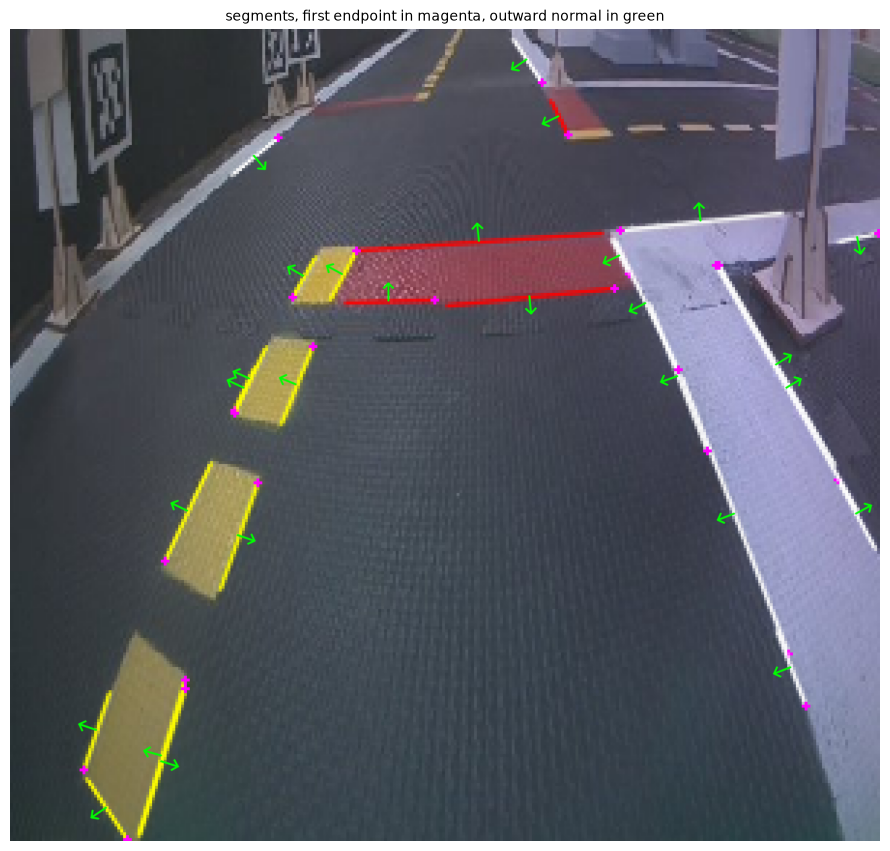

In [ ]:
# Green arrows point from each segment's midpoint *out of the paint* - the side
# the probe found empty. Within one marking they should all agree; where they
# disagree, both probes landed on the same side and the answer was a coin flip.
annotated = cropped.copy()
DRAW_COLORS = {"WHITE": (255, 255, 255), "YELLOW": (0, 255, 255), "RED": (0, 0, 255)}
SCALE = 5          # upscale factor for the display
ARROW_PX = 6       # arrow length, in original (pre-upscale) pixels

normals_by_color = {}
arrows = []
for name, lines in detections.items():
    if lines is None:
        continue
    n = orient(lines, masks[name], do_swap=False) if len(lines) else np.zeros((0, 2))
    normals_by_color[name] = n
    for (x1, y1, x2, y2), nv in zip(lines, n):
        cv2.line(annotated, (x1, y1), (x2, y2), DRAW_COLORS[name], 1, cv2.LINE_AA)
        cv2.circle(annotated, (x1, y1), 1, (255, 0, 255), -1)
        mx, my = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        arrows.append(((mx, my), nv))

big = cv2.resize(annotated, (annotated.shape[1] * SCALE, annotated.shape[0] * SCALE),
                 interpolation=cv2.INTER_NEAREST)

# Drawn after the upscale so the arrowheads are big enough to read.
for (mx, my), nv in arrows:
    tail = (int(round(mx * SCALE)), int(round(my * SCALE)))
    tip = (int(round((mx + ARROW_PX * nv[0]) * SCALE)),
           int(round((my + ARROW_PX * nv[1]) * SCALE)))
    if tip != tail:
        cv2.arrowedLine(big, tail, tip, (0, 255, 0), 2, cv2.LINE_AA, tipLength=0.4)

show(big, titles=["segments, first endpoint in magenta, outward normal in green"], size=9)
